# Retail Sales Forecasting: EDA and Feature Engineering

This notebook loads and explores the Walmart retail sales forecasting dataset. The goal is to explore sales trends, seasonality, and holiday effects while engineering predictive features for downstream forecasting models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# show me every column of dataframe instead of cutting it off at a certain number of columns
pd.set_option("display.max_columns", None)

In [2]:
# load the datasets and display the shape

train = pd.read_csv("../data/train.csv")
features = pd.read_csv("../data/features.csv")
stores = pd.read_csv("../data/stores.csv")

print("Train shape:", train.shape)
print("Features shape:", features.shape)
print("Stores shape:", stores.shape)

Train shape: (421570, 5)
Features shape: (8190, 12)
Stores shape: (45, 3)


In [3]:
# Train dataset -- sales table (main dataset)
train.head()
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 13.3 MB


,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [ ]:
# external factors -- could influence sales, but are not sales themselves
features.head()
features.info()
features.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   str    
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), str(1)
memory usage: 712.0 KB


,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
std,12.987966,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259
min,1.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000


In [5]:
# store information
stores.head()
stores.info()
stores.describe()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Store   45 non-null     int64
 1   Type    45 non-null     str  
 2   Size    45 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.2 KB


,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


In [6]:
# merge the datasets

# merge train and features
df = train.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

# merge the above train/features df with the stores df
df = df.merge(
    stores,
    on="Store",
    how="left"
)

# verify the merge is sound
print(df.shape)
df.head()

(421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [7]:
# check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  str    
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), str(2)
memory usage: 48.6 MB


In [8]:
# check for missing values

missing = df.isnull().sum().sort_values(ascending=False)

missing

MarkDown2       310322
MarkDown4       286603
MarkDown3       284479
MarkDown1       270889
MarkDown5       270138
Store                0
Date                 0
Dept                 0
Fuel_Price           0
Temperature          0
IsHoliday            0
Weekly_Sales         0
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

In [9]:
# only display columns with missing values
missing[missing > 0]

MarkDown2    310322
MarkDown4    286603
MarkDown3    284479
MarkDown1    270889
MarkDown5    270138
dtype: int64

In [10]:
# percentage of missing values
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_percent[missing_percent > 0]

MarkDown2    73.611025
MarkDown4    67.984676
MarkDown3    67.480845
MarkDown1    64.257181
MarkDown5    64.079038
dtype: float64

In [11]:
# duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Date Conversion

Convert the `Date` column from a string to a datetime object so we can extract temporal features and perform time series analysis.

In [12]:
# convert Date from a string to datetime
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  str           
 15  Size          421570 non-nul

## Exploratory Data Analysis

In this section, we explore the merged dataset to better understand sales patterns, distributions, and relationships between variables before building forecasting models.

### Weekly Sales Distribution

In [13]:
# summary statistics for the target variable
df["Weekly_Sales"].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

### Distribution of Weekly Sales

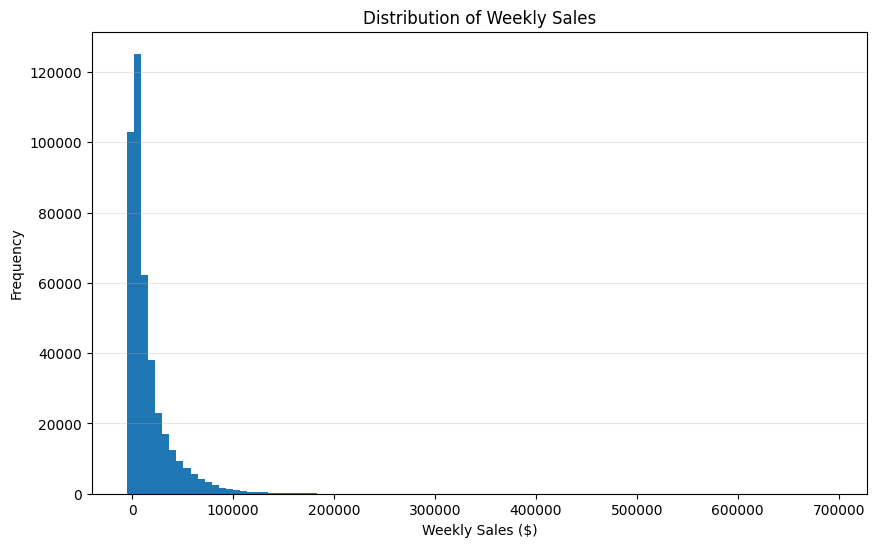

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(df["Weekly_Sales"], bins=100)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales ($)")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()

The distribution is strongly right-skewed, indicating that a relatively small number of store-department combinations generate exceptionally high weekly sales. As a result, the mean weekly sales is noticeably higher than the median, suggesting that aggregate statistics are influenced by these high-value observations.

### Weekly Sales Over Time

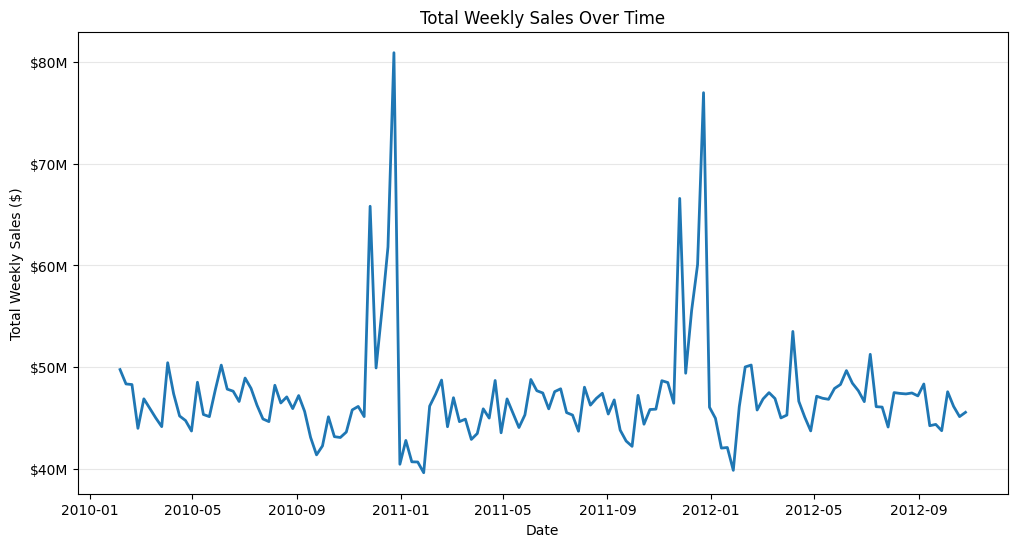

In [15]:
# aggregate weekly sales across all stores and departments
weekly_sales = (
    df.groupby("Date")["Weekly_Sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"],
    linewidth=2
)

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales ($)")

# Format y-axis in millions
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.0f}M')
)

plt.grid(axis="y", alpha=0.3)

plt.show()

### Observations

- Total weekly sales remain relatively stable throughout most of the observed period.
- Large recurring spikes occur near the end of each year, indicating strong annual seasonality associated with holiday shopping periods.
- Holiday weeks generate substantially higher total sales than typical weeks, suggesting that seasonality should be considered during model development.

### Holiday vs. Non-Holiday Sales

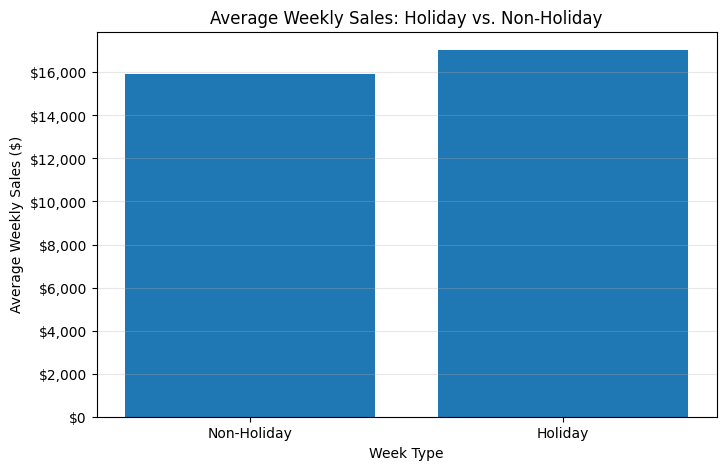

In [16]:
# compare weekly sales for holiday and non-holiday weeks

holiday_sales = (
    df.groupby("IsHoliday")["Weekly_Sales"]
      .mean()
      .reset_index()
)

holiday_sales["IsHoliday"] = holiday_sales["IsHoliday"].map({
    False: "Non-Holiday",
    True: "Holiday"
})

plt.figure(figsize=(8, 5))

plt.bar(
    holiday_sales["IsHoliday"],
    holiday_sales["Weekly_Sales"]
)

plt.title("Average Weekly Sales: Holiday vs. Non-Holiday")
plt.xlabel("Week Type")
plt.ylabel("Average Weekly Sales ($)")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
)

plt.grid(axis="y", alpha=0.3)

plt.show()

### Observations

- Holiday weeks exhibit higher average weekly sales than non-holiday weeks.
- The increase at the department level is modest compared to the large spikes observed in total company sales.
- This suggests that the dramatic increases in aggregate sales are driven by many departments experiencing moderate increases simultaneously rather than a few departments experiencing extremely large increases.

## Feature Engineering

### Calendar Features

In [17]:
# create calendar-based features from the Date column

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

In [18]:
df[["Date", "Year", "Quarter", "Month", "Week"]].head()

,Date,Year,Quarter,Month,Week
0,2010-02-05,2010,1,2,5
1,2010-02-12,2010,1,2,6
2,2010-02-19,2010,1,2,7
3,2010-02-26,2010,1,2,8
4,2010-03-05,2010,1,3,9


### Lag Features

In [19]:
# sort data before creating lag features
df = df.sort_values(["Store", "Dept", "Date"])

# create lag features
df["Lag_1"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)
df["Lag_4"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(4)
df["Lag_52"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(52)

In [ ]:
# verify the engineered lag features

df[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "Lag_1",
        "Lag_4",
        "Lag_52"
    ]
].head(15)

,Store,Dept,Date,Weekly_Sales,Lag_1,Lag_4,Lag_52
0,1,1,2010-02-05,24924.50,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,24924.50,NaN,NaN
2,1,1,2010-02-19,41595.55,46039.49,NaN,NaN
3,1,1,2010-02-26,19403.54,41595.55,NaN,NaN
4,1,1,2010-03-05,21827.90,19403.54,24924.50,NaN
5,1,1,2010-03-12,21043.39,21827.90,46039.49,NaN
6,1,1,2010-03-19,22136.64,21043.39,41595.55,NaN
7,1,1,2010-03-26,26229.21,22136.64,19403.54,NaN
8,1,1,2010-04-02,57258.43,26229.21,21827.90,NaN
9,1,1,2010-04-09,42960.91,57258.43,21043.39,NaN


### Rolling Features

In [21]:
# create rolling average features
# shift 1 is intentional -- prevents data leakage

df["Rolling_Mean_4"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .transform(lambda x: x.shift(1).rolling(window=4).mean())
)

df["Rolling_Mean_12"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .transform(lambda x: x.shift(1).rolling(window=12).mean())
)

In [22]:
# verify data looks good
# these rolling features help answer the question of "What has been happening recently?"

df[
    [
        "Date",
        "Weekly_Sales",
        "Lag_1",
        "Rolling_Mean_4",
        "Rolling_Mean_12"
    ]
].head(20)

,Date,Weekly_Sales,Lag_1,Rolling_Mean_4,Rolling_Mean_12
0,2010-02-05,24924.50,NaN,NaN,NaN
1,2010-02-12,46039.49,24924.50,NaN,NaN
2,2010-02-19,41595.55,46039.49,NaN,NaN
3,2010-02-26,19403.54,41595.55,NaN,NaN
4,2010-03-05,21827.90,19403.54,32990.7700,NaN
5,2010-03-12,21043.39,21827.90,32216.6200,NaN
6,2010-03-19,22136.64,21043.39,25967.5950,NaN
7,2010-03-26,26229.21,22136.64,21102.8675,NaN
8,2010-04-02,57258.43,26229.21,22809.2850,NaN
9,2010-04-09,42960.91,57258.43,31666.9175,NaN


### Data Preparation for Modeling

In [23]:
# check missing values after feature engineering

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

MarkDown2          310322
MarkDown4          286603
MarkDown3          284479
MarkDown1          270889
MarkDown5          270138
Lag_52             160487
Rolling_Mean_12     38615
Rolling_Mean_4      13134
Lag_4               13134
Lag_1                3331
dtype: int64

### Summary

In this notebook, we:

- Loaded and merged the Walmart datasets.
- Assessed data quality.
- Explored sales patterns and holiday effects.
- Created calendar features.
- Engineered lag features.
- Engineered rolling average features.

The engineered dataset will be used in the next notebook to build and evaluate forecasting models.

In [24]:
# save engineered dataset for modeling

df.to_csv("../data/engineered_sales_data.csv", index=False)